# 🔄 Customer Churn Predictor

> Predicting whether a customer will churn based on behavioral and demographic features.

## 📁 Dataset
- **Source:** Kaggle `Predict Customer Churn` Competition Dataset
- **Files:** `train.csv`, `test.csv`

## 🎯 Objective
Build a machine learning model that accurately classifies customers as churned or retained and stores that data with the possibility in a different csv,
helping businesses identify at-risk customers before they leave.

## 🔧 Workflow
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing & Feature Engineering
3. Model Building & Evaluation

## Section 1 :- Loading data and preview

In [1]:
import pandas as pd

test_df = pd.read_csv('test.csv')

train_df = pd.read_csv('train.csv')
train_df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [2]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

## Section 2 :- Data pre-processing

### Boolean Mapping

In [3]:
#Creating the mapping variable

yes_no_mapping = {'Yes':1, 'No':0}

* Encoding Partner

In [4]:
train_df['Partner'] = train_df['Partner'].map(yes_no_mapping)
test_df['Partner'] = test_df['Partner'].map(yes_no_mapping)

* Encoding Dependents 

In [5]:
train_df['Dependents'] = train_df['Dependents'].map(yes_no_mapping)
test_df['Dependents'] = test_df['Dependents'].map(yes_no_mapping)

* Encoding PhoneService

In [6]:
train_df['PhoneService'] = train_df['PhoneService'].map(yes_no_mapping)
test_df['PhoneService'] = test_df['PhoneService'].map(yes_no_mapping)

* Encoding 	PaperlessBilling	

In [7]:
train_df['PaperlessBilling'] = train_df['PaperlessBilling'].map(yes_no_mapping)
test_df['PaperlessBilling'] = test_df['PaperlessBilling'].map(yes_no_mapping)

In [8]:
train_df['Churn'] = train_df['Churn'].map(yes_no_mapping)

### Converting Gender

In [9]:
gender_mapping = {'Female': 1, 'Male': 0}
train_df['gender'] = train_df['gender'].map(gender_mapping)
test_df['gender'] = test_df['gender'].map(gender_mapping)

### Creating Dummies

In [10]:
#Train Data
train_df = pd.get_dummies(train_df, columns=['InternetService'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['OnlineSecurity'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['OnlineBackup'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['MultipleLines'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['DeviceProtection'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['TechSupport'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['StreamingTV'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['StreamingMovies'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['PaymentMethod'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['Contract'], drop_first=True)

#Test Data
test_df = pd.get_dummies(test_df, columns=['InternetService'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['OnlineSecurity'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['OnlineBackup'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['MultipleLines'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['DeviceProtection'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['TechSupport'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['StreamingTV'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['StreamingMovies'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['PaymentMethod'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Contract'], drop_first=True)


In [11]:
bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)

bool_cols = test_df.select_dtypes(include='bool').columns
test_df[bool_cols] = test_df[bool_cols].astype(int)

## Section 3 :- Checking Correlation

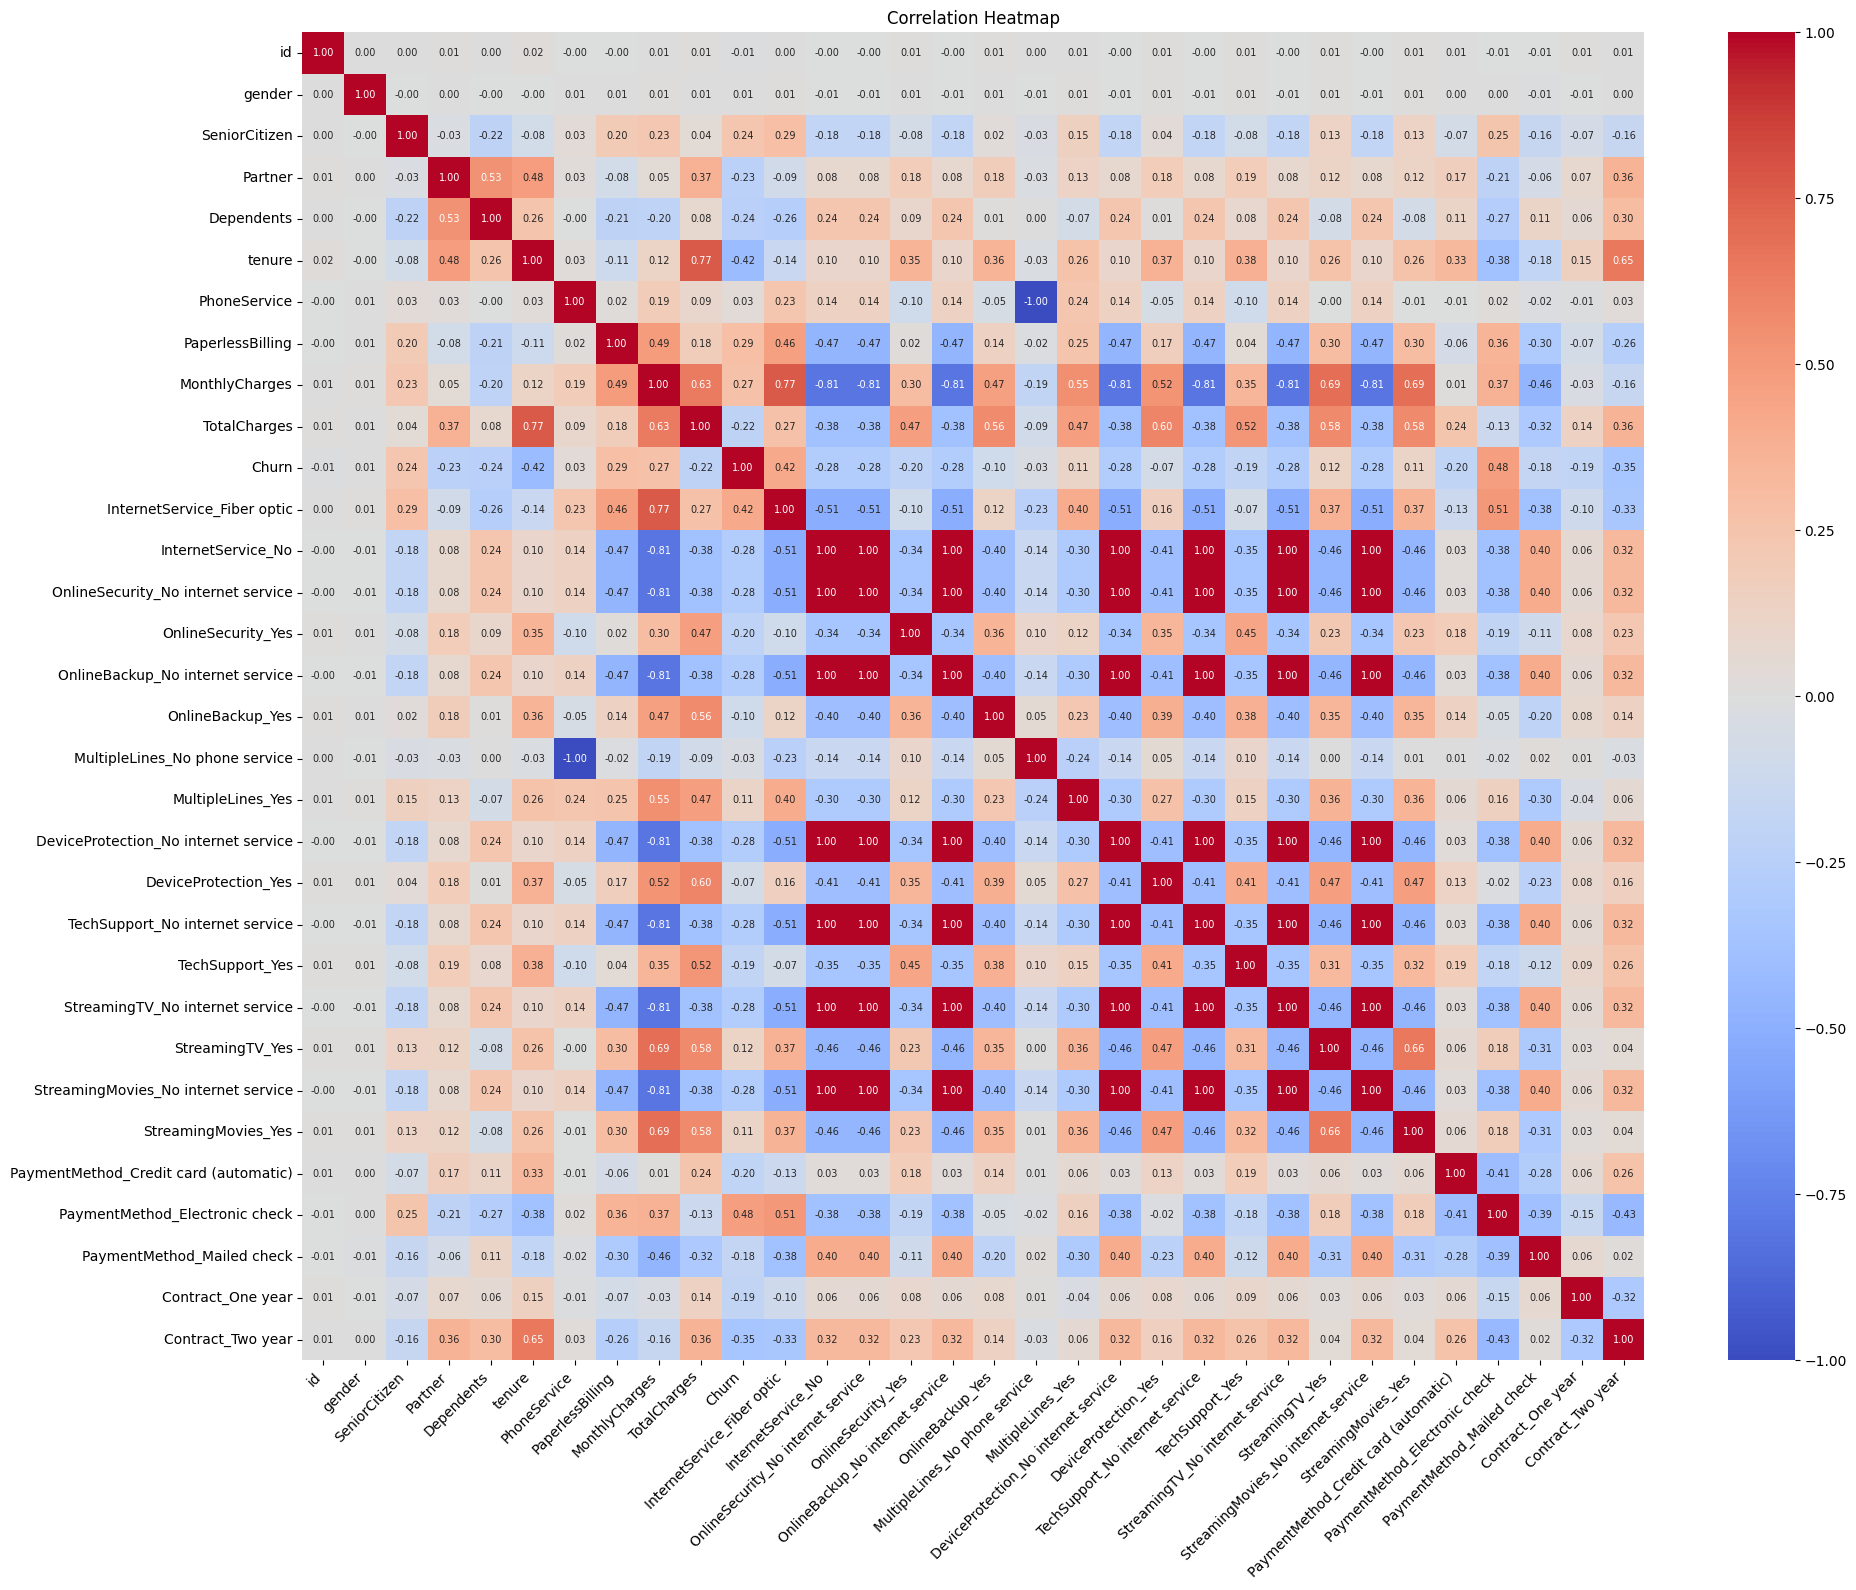

In [12]:
#correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', 
            annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
#Checking Correlation with churn
train_df.corrwith(train_df['Churn']).sort_values(ascending=False)

Churn                                    1.000000
PaymentMethod_Electronic check           0.476255
InternetService_Fiber optic              0.418819
PaperlessBilling                         0.285107
MonthlyCharges                           0.272997
SeniorCitizen                            0.236362
StreamingTV_Yes                          0.117280
MultipleLines_Yes                        0.114951
StreamingMovies_Yes                      0.114589
PhoneService                             0.034843
gender                                   0.006808
id                                      -0.012971
MultipleLines_No phone service          -0.034843
DeviceProtection_Yes                    -0.074228
OnlineBackup_Yes                        -0.100109
PaymentMethod_Mailed check              -0.178668
Contract_One year                       -0.189436
TechSupport_Yes                         -0.191011
PaymentMethod_Credit card (automatic)   -0.201075
OnlineSecurity_Yes                      -0.204544


## Section 4 :- Training the Model

### Making the features and target

In [14]:
from sklearn.model_selection import train_test_split

features = train_df.drop(columns=['Churn', 'gender', 'id'])
target = train_df['Churn']

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=27)

### Building and fitting the model

## Section 5 :- Using XGBoost

In [15]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, n_jobs=-1, scale_pos_weight=3, eval_metric='logloss')
xgb_model.fit(features_train, target_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

target_pred = xgb_model.predict(features_test)

print("Accuracy:", accuracy_score(target_test, target_pred))
print("Confusion Matrix:\n", confusion_matrix(target_test, target_pred))
print("Report:\n", classification_report(target_test, target_pred))

Accuracy: 0.8277753935997442
Confusion Matrix:
 [[75452 16632]
 [ 3835 22920]]
Report:
               precision    recall  f1-score   support

           0       0.95      0.82      0.88     92084
           1       0.58      0.86      0.69     26755

    accuracy                           0.83    118839
   macro avg       0.77      0.84      0.79    118839
weighted avg       0.87      0.83      0.84    118839



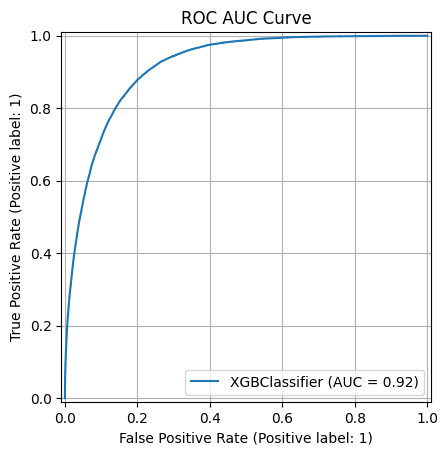

In [19]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(xgb_model, features_test, target_test)
plt.title("ROC AUC Curve")
plt.grid(True)
plt.show()

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


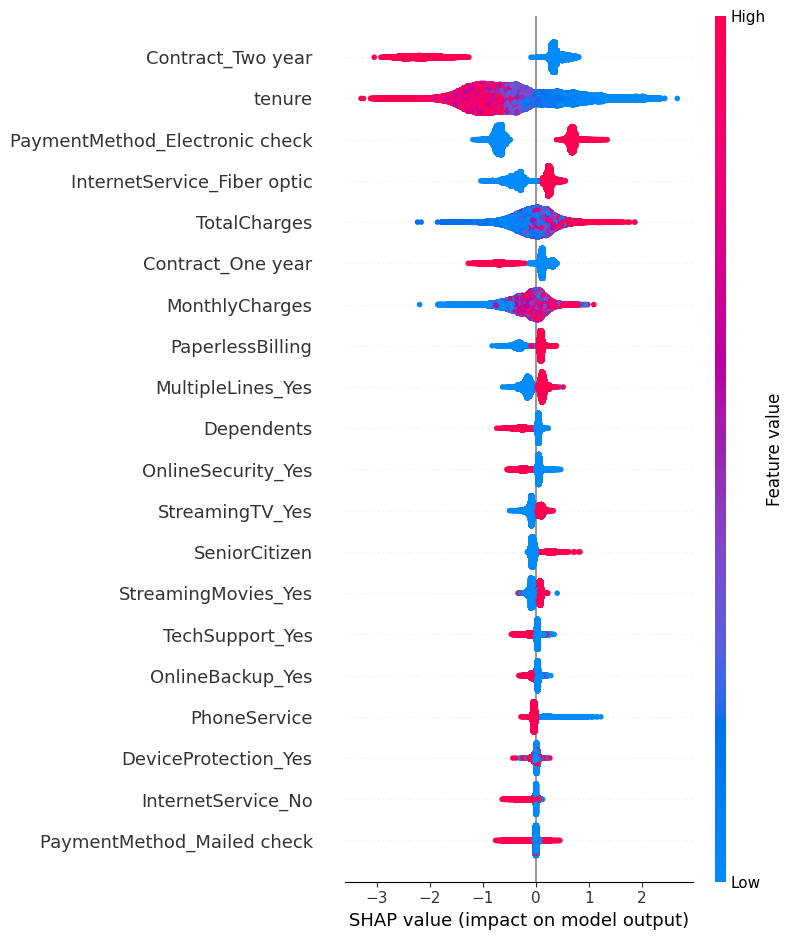

In [22]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(features_test)

shap.summary_plot(shap_values, features_test)

### It is clear that XGBoost has a better overall performance hence XGBoost will be used to check `test.csv` 

## Section 6 :- Finding Churns for `test.csv`

### Making the XGBoost Model on the whole train data

In [212]:
xgb_model = XGBClassifier(random_state=42, n_jobs=-1, scale_pos_weight=3, eval_metric='logloss')
xgb_model.fit(features, target)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)

### Making test_features

In [213]:
test_features = test_df.drop(columns=['id', 'gender'])

### Making Predictions and Saving it in `submission.csv`

In [214]:
test_predictions = xgb_model.predict(test_features)

submission = pd.DataFrame({
    'id': test_df['id'],
    'Churn': test_predictions
})

submission.to_csv('submission.csv', index=False)